# NEU steel surface defects - what the dataset contains

**Arkon Manufacturing AI | Module: CV Multi-class | Department: Rolling Mill**

Greyscale photographs of hot-rolled steel strip, six defect types, in a train
and a validation folder the dataset ships already split. Module 04 of the
Arkon platform trains on them and feeds the Quality Steering Cell through the
risk event adapter.

This notebook asks what is in those folders before anything is fitted. Every
image is opened and every annotation is parsed rather than a sample of them,
because this dataset labels the same picture twice: once by the folder it sits
in, and once by the bounding boxes shipped beside it.

## 1. Imports and configuration

The shared helpers live in `notebooks/utils`. This cell puts that directory on the path.

In [1]:
import sys
from pathlib import Path

# notebooks/ holds the shared helpers; this notebook sits two levels below it
_nb_root = Path('../..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import save_figure

print('arkon_utils loaded')

arkon_utils loaded


The libraries, the paths and the six class names. Paths stay relative so no local
drive layout is printed into a public repository. There is no metrics file to
open here: this module ships nothing yet, and notebook 03 is what produces it.

In [2]:
import hashlib
import time
import xml.etree.ElementTree as ET
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

ASSETS = 'cv'
RAW_DIR = Path('../../../data/04_neu/raw')
SPLITS = ('train', 'validation')

CLASSES = sorted(p.name for p in (RAW_DIR / 'train' / 'images').iterdir() if p.is_dir())

print(f'python  {sys.version.split()[0]}')
print(f'pandas  {pd.__version__}')
print(f'pillow  {Image.__version__}')
print(f'raw folder present: {RAW_DIR.is_dir()}')
print(f'classes ({len(CLASSES)}): {CLASSES}')

python  3.12.10
pandas  2.3.3
pillow  12.2.0
raw folder present: True
classes (6): ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


## 2. One scan, and everything after it is a query

Every image is opened once and every annotation file is parsed once. This cell
records size, mode, channel structure, brightness and two content hashes for all
of them, plus one row per bounding box, and every section below queries those two
tables instead of reading the disk again.

The annotation folders are flat - one directory of XML per split, not one per
class - so the link back to an image is the file stem, and that is what makes
section 3 possible at all.

In [3]:
def scan_images(root):
    """Open every image under root/<split>/images/<class> once and record what it is."""
    rows = []
    for split in SPLITS:
        for folder in sorted(p for p in (root / split / 'images').iterdir() if p.is_dir()):
            for path in sorted(folder.iterdir()):
                raw = path.read_bytes()
                with Image.open(path) as image:
                    width, height = image.size
                    mode, fmt = image.mode, image.format
                    colour = np.asarray(image)
                    grey = np.asarray(image.convert('L'))
                identical = (colour.ndim == 3 and colour.shape[2] == 3
                             and np.array_equal(colour[..., 0], colour[..., 1])
                             and np.array_equal(colour[..., 1], colour[..., 2]))
                rows.append({
                    'split': split, 'folder_class': folder.name, 'stem': path.stem,
                    'bytes': len(raw), 'width': width, 'height': height,
                    'mode': mode, 'format': fmt, 'channels_identical': bool(identical),
                    'mean_intensity': float(grey.mean()),
                    'std_intensity': float(grey.std()),
                    'file_sha': hashlib.sha256(raw).hexdigest(),
                    'pixel_sha': hashlib.sha256(grey.tobytes()).hexdigest(),
                })
    return pd.DataFrame(rows)


def scan_boxes(root):
    """One row per bounding box, plus the split the XML file was filed under."""
    rows, unreadable = [], []
    for split in SPLITS:
        for path in sorted((root / split / 'annotations').glob('*.xml')):
            try:
                node = ET.parse(path).getroot()
            except ET.ParseError as error:
                unreadable.append((split, path.name, str(error)))
                continue
            width = int(node.findtext('size/width'))
            height = int(node.findtext('size/height'))
            for obj in node.findall('object'):
                box = obj.find('bndbox')
                xmin, ymin = int(box.findtext('xmin')), int(box.findtext('ymin'))
                xmax, ymax = int(box.findtext('xmax')), int(box.findtext('ymax'))
                rows.append({
                    'ann_split': split, 'stem': path.stem, 'box_class': obj.findtext('name'),
                    'img_width': width, 'img_height': height,
                    'xmin': xmin, 'ymin': ymin, 'xmax': xmax, 'ymax': ymax,
                    'box_width': xmax - xmin, 'box_height': ymax - ymin,
                    'area_share': (xmax - xmin) * (ymax - ymin) / (width * height),
                    'aspect': (xmax - xmin) / max(ymax - ymin, 1),
                })
    return pd.DataFrame(rows), unreadable


t0 = time.time()
images = scan_images(RAW_DIR)
boxes, unreadable = scan_boxes(RAW_DIR)
print(f'{len(images):,} images opened and {len(boxes):,} boxes parsed in {time.time() - t0:.1f}s')
print(f'annotation files that would not parse: {len(unreadable)}')
for row in unreadable:
    print('   ', row)
print()
print(images[['split', 'folder_class', 'stem', 'bytes', 'width', 'height', 'mode',
              'mean_intensity']].head(3).to_string(index=False))

1,800 images opened and 4,189 boxes parsed in 2.2s
annotation files that would not parse: 0

split folder_class        stem  bytes  width  height mode  mean_intensity
train      crazing   crazing_1  22873    200     200  RGB      160.636500
train      crazing  crazing_10  21377    200     200  RGB      136.991575
train      crazing crazing_100  21837    200     200  RGB      138.498700


Every XML in the two folders parsed. The zero-byte file the next section finds is
not in this count, because it does not end in `.xml` and the glob never saw it.

## 3. Do the image folders and the annotation folders agree

The dataset is two parallel label systems over the same 1,800 pictures, and
nothing in this repository had ever checked that they line up. Three questions:
does every image have an annotation, does every annotation have an image, and do
the two agree about which split a picture belongs to.

In [4]:
image_stems = {split: set(images.loc[images['split'] == split, 'stem']) for split in SPLITS}
ann_stems = {split: set(boxes.loc[boxes['ann_split'] == split, 'stem']) for split in SPLITS}

print(f'{"":<12}{"images":>9}{"annotations":>13}')
for split in SPLITS:
    print(f'{split:<12}{len(image_stems[split]):>9,}{len(ann_stems[split]):>13,}')
print(f'{"total":<12}{sum(len(v) for v in image_stems.values()):>9,}'
      f'{sum(len(v) for v in ann_stems.values()):>13,}')
print()

all_images = set().union(*image_stems.values())
all_anns = set().union(*ann_stems.values())
print(f'images with no annotation anywhere : {len(all_images - all_anns)}')
print(f'annotations with no image anywhere : {len(all_anns - all_images)}')

misfiled = [(stem, split) for split in SPLITS for stem in image_stems[split]
            if stem not in ann_stems[split] and stem in all_anns]
print(f'stems whose image and annotation are filed under different splits: {len(misfiled)}')
for stem, split in sorted(misfiled):
    other = [s for s in SPLITS if stem in ann_stems[s]][0]
    print(f'    {stem}: image in {split}/images, annotation in {other}/annotations')

               images  annotations
train           1,440        1,439
validation        360          361
total           1,800        1,800

images with no annotation anywhere : 0
annotations with no image anywhere : 0
stems whose image and annotation are filed under different splits: 1
    crazing_240: image in train/images, annotation in validation/annotations


**One picture is filed on both sides of the split at once.** `crazing_240.jpg`
sits in `train/images/crazing`, and `crazing_240.xml` sits in
`validation/annotations`. Every other stem agrees with itself, and no image is
missing an annotation.

For the classification task decided for this module the boxes are never loaded,
so this costs nothing. For a detection loader it is exactly the kind of defect
that does not raise: pair the two folders by split and the training set silently
loses an image while the validation set gains a label with no picture under it.

The annotation folder also carries one file that is not data.

In [5]:
junk = [p for split in SPLITS for p in (RAW_DIR / split / 'annotations').iterdir()
        if p.suffix.lower() != '.xml']
print(f'non-XML files sitting in the annotation folders: {len(junk)}')
for path in junk:
    print(f'    {path.parent.parent.name}/{path.parent.name}/{path.name}   {path.stat().st_size} bytes')

non-XML files sitting in the annotation folders: 1
    train/annotations/.crazing_21.xml.BXARk2LvYS   0 bytes


A zero-byte file left behind by a file-sync client. It is not a label, and a
loader that globs the folder rather than the `*.xml` pattern would try to parse
it. Named here so the next reader does not rediscover it as a mystery.

## 4. Image properties, measured on all of them

Two questions a sample could not answer: is every image the same shape, and are
these really colour photographs.

In [6]:
print('shape      ', images.groupby(['width', 'height']).size().to_dict())
print('mode       ', images['mode'].value_counts().to_dict())
print('format     ', images['format'].value_counts().to_dict())
print('channels   ', f'R == G == B in {images["channels_identical"].sum():,} of {len(images):,} images')
print('file size  ', f'{images["bytes"].min():,} to {images["bytes"].max():,} bytes, '
                     f'median {int(images["bytes"].median()):,}')
print('brightness ', f'{images["mean_intensity"].mean() / 255:.4f} mean over the dataset, '
                     f'per-image spread {images["mean_intensity"].std() / 255:.4f}')
print()
print('the annotations declare a channel depth too:')
depths = Counter()
for split in SPLITS:
    for path in (RAW_DIR / split / 'annotations').glob('*.xml'):
        depths[ET.parse(path).getroot().findtext('size/depth')] += 1
print('   <depth> values across all annotation files:', dict(depths))

shape       {(200, 200): 1800}
mode        {'RGB': 1800}
format      {'JPEG': 1800}
channels    R == G == B in 1,800 of 1,800 images
file size   5,704 to 24,150 bytes, median 15,281
brightness  0.5031 mean over the dataset, per-image spread 0.1747

the annotations declare a channel depth too:


   <depth> values across all annotation files: {'1': 1800}


**The same trap casting has, and worth naming again.** Every file decodes to
three identical channels, and the annotations agree with themselves that the
depth is 1. The pipeline still normalises with the ImageNet per-channel
constants, so three copies of one number leave the transform as three different
ones. Notebook 02 measures what that costs here. It matters because a reader of
the model card sees "200 x 200 RGB" and reasonably assumes colour carries
information.

## 5. Class balance

Casting ships two folders with different class ratios and a large imbalance. This
cell asks what NEU ships instead.

folder_class  crazing  inclusion  patches  pitted_surface  rolled-in_scale  scratches  total
split                                                                                       
train             240        240      240             240              240        240   1440
validation         60         60       60              60               60         60    360

train: 1 distinct class count, 240 to 240 images per class
validation: 1 distinct class count, 60 to 60 images per class

the validation folder is 20.0% of the 1,800 images


  ✓ Saved → assets\cv\neu_eda_class_counts.png


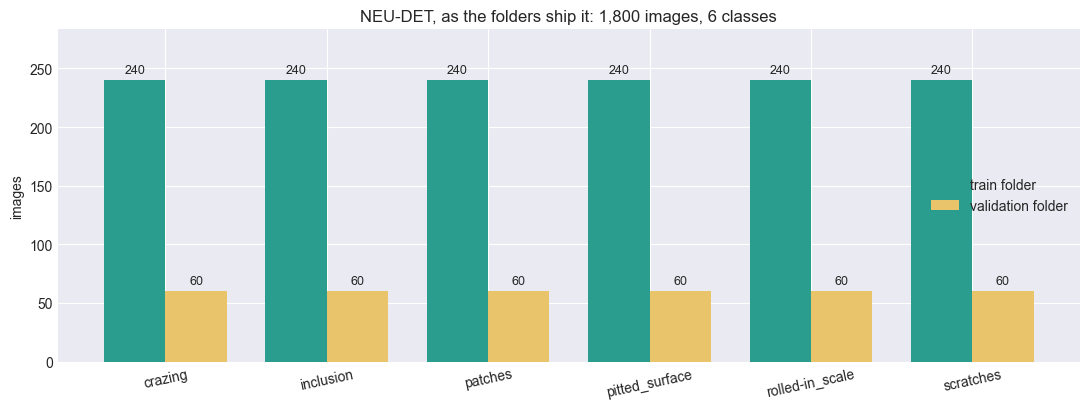

In [7]:
counts = (images.groupby(['split', 'folder_class']).size()
          .unstack(fill_value=0)[CLASSES])
counts['total'] = counts.sum(axis=1)
print(counts.to_string())
print()
per_class = counts[CLASSES].nunique(axis=1)
for split in SPLITS:
    print(f'{split}: {per_class[split]} distinct class count'
          f'{"" if per_class[split] == 1 else "s"}, '
          f'{int(counts.loc[split, CLASSES].min())} to {int(counts.loc[split, CLASSES].max())} images per class')
print()
print(f'the validation folder is {counts.loc["validation", "total"] / counts["total"].sum():.1%} '
      f'of the {int(counts["total"].sum()):,} images')

fig, ax = plt.subplots(figsize=(11, 4.2))
positions = np.arange(len(CLASSES))
for offset, split, colour in ((-0.19, 'train', '#2a9d8f'), (0.19, 'validation', '#e9c46a')):
    values = counts.loc[split, CLASSES].to_numpy()
    bars = ax.bar(positions + offset, values, 0.38, label=f'{split} folder', color=colour)
    ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
ax.set_xticks(positions)
ax.set_xticklabels(CLASSES, rotation=12)
ax.set_ylabel('images')
ax.set_ylim(0, int(counts[CLASSES].to_numpy().max()) * 1.18)
ax.legend()
ax.set_title(f'NEU-DET, as the folders ship it: {int(counts["total"].sum()):,} images, '
             f'{len(CLASSES)} classes')
fig.tight_layout()
save_figure(fig, 'neu_eda_class_counts', subfolder=ASSETS)
plt.show()

**Exactly balanced, 240 and 60 per class in the two folders.** That is a
constructed dataset rather than a production sample, and it has two consequences
worth carrying forward. Accuracy is a fair headline here in a way it is not for
Scania, because chance is 1 in 6 for every class. And the balance is a property
of the benchmark, not of a rolling mill, so nothing measured on it says how often
each defect actually occurs on a line.

## 6. The duplicate census

Casting's published split turned out to share 64 byte-identical images between
its train and test folders. The scan already carries both hashes, so asking the
same question here costs one groupby. Equal file bytes would mean a copied file;
equal pixels but different bytes would mean a re-encoding.

In [8]:
def duplicate_groups(frame, column):
    """Every set of rows sharing a hash, keyed by that hash."""
    sizes = frame.groupby(column).size()
    return {key: frame[frame[column] == key] for key in sizes[sizes > 1].index}


by_bytes = duplicate_groups(images, 'file_sha')
by_pixels = duplicate_groups(images, 'pixel_sha')

print(f'{"hashed on":<18}{"unique":>9}{"groups":>9}{"extra copies":>14}')
for tag, column, groups in (('file bytes', 'file_sha', by_bytes),
                            ('decoded pixels', 'pixel_sha', by_pixels)):
    extra = sum(len(g) - 1 for g in groups.values())
    print(f'{tag:<18}{images[column].nunique():>9,}{len(groups):>9,}{extra:>14,}')
print()

across = {key: g for key, g in by_pixels.items() if g['split'].nunique() > 1}
print(f'duplicate groups spanning the train and validation folders: {len(across)}')
print(f'duplicate groups inside one folder: {len(by_pixels) - len(across)}')
for group in by_pixels.values():
    rows = ', '.join(f'{r.split}/{r.folder_class}/{r.stem}' for r in group.itertuples())
    print(f'    {rows}')

hashed on            unique   groups  extra copies
file bytes            1,799        1             1
decoded pixels        1,799        1             1

duplicate groups spanning the train and validation folders: 0
duplicate groups inside one folder: 1
    train/patches/patches_101, train/patches/patches_105


**No image crosses the split.** The one duplicate pair is two copies of the same
picture inside `train/patches`, which costs a fraction of one image of training
signal and nothing at all in the reported numbers. So the qualification casting's
model card has to carry does not apply to this module, and that is a statement
about this dataset rather than about the care taken with it.

## 7. What the boxes say that the folder name does not

The folder a picture sits in gives it one class. The annotation beside it gives a
list of boxes, and that list does not have to be one class long. Which of the two
is the label matters, because the module trained here is a single-label
classifier and can only carry one of them.

In [9]:
folder_class = images.set_index('stem')['folder_class']
per_stem = boxes.groupby('stem')['box_class'].agg(list)

rows = []
for stem, names in per_stem.items():
    if stem not in folder_class.index:
        continue
    unique = set(names)
    rows.append({'stem': stem, 'folder_class': folder_class[stem],
                 'n_boxes': len(names), 'n_classes': len(unique),
                 'folder_class_in_boxes': folder_class[stem] in unique,
                 'extra': sorted(unique - {folder_class[stem]})})
agreement = pd.DataFrame(rows)

print(f'images checked                                     : {len(agreement):,}')
print(f'boxes per image                                    : '
      f'{agreement["n_boxes"].min()} to {agreement["n_boxes"].max()}, '
      f'mean {agreement["n_boxes"].mean():.2f}')
print(f'images where the folder class is NOT among its boxes: '
      f'{(~agreement["folder_class_in_boxes"]).sum()}')
mixed = agreement[agreement['n_classes'] > 1]
print(f'images carrying more than one defect class         : {len(mixed):,} '
      f'({len(mixed) / len(agreement):.1%})')
print()
pairs = Counter((row.folder_class, other) for row in mixed.itertuples() for other in row.extra)
print(f'{"filed as":<18}{"also contains":<18}{"images":>7}')
for (filed, other), n in pairs.most_common():
    print(f'{filed:<18}{other:<18}{n:>7}')

images checked                                     : 1,800


boxes per image                                    : 1 to 9, mean 2.33
images where the folder class is NOT among its boxes: 0
images carrying more than one defect class         : 123 (6.8%)

filed as          also contains      images
scratches         inclusion              49
pitted_surface    patches                37
patches           inclusion              29
crazing           patches                 4
pitted_surface    inclusion               3
crazing           inclusion               1
scratches         patches                 1
scratches         pitted_surface          1


**The folder label is never wrong, and for 123 images it is incomplete.** In no
picture is the folder class missing from its own boxes, so single-label training
is not learning a false label. But 6.8 per cent of the dataset contains a second
defect type that the folder name discards, and a single-label classifier has no
way to be right about those two at once. Whatever accuracy notebook 03 reports,
this is the part of it that is not the model's to win.

The three common pairs are physically sensible rather than random: scratches with
inclusions, pitted surface with patches, patches with inclusions.

The boxes carry one more thing the folder name cannot: how much of the frame each
defect actually occupies.

In [10]:
shape = (boxes.groupby('box_class')
         .agg(boxes=('area_share', 'size'),
              median_area=('area_share', 'median'),
              p90_area=('area_share', lambda s: s.quantile(0.90)),
              covers_half=('area_share', lambda s: (s >= 0.5).mean()),
              median_aspect=('aspect', 'median'))
         .loc[CLASSES])
print(shape.round(3).to_string())
print()
print('median box area as a fraction of the 200 x 200 frame, smallest to largest:')
for name, value in shape['median_area'].sort_values().items():
    print(f'    {name:<18}{value:.3f}')

                 boxes  median_area  p90_area  covers_half  median_aspect
box_class                                                                
crazing            689        0.211     0.379        0.012          1.795
inclusion         1011        0.041     0.178        0.000          0.367
patches            881        0.093     0.278        0.003          0.726
pitted_surface     432        0.555     0.970        0.583          0.759
rolled-in_scale    628        0.123     0.277        0.002          0.978
scratches          548        0.075     0.163        0.000          0.178

median box area as a fraction of the 200 x 200 frame, smallest to largest:
    inclusion         0.041
    scratches         0.075
    patches           0.093
    rolled-in_scale   0.123
    crazing           0.211
    pitted_surface    0.555


Two things follow. **The defects are localised, except one.** Five classes have a
median box under a quarter of the frame and `inclusion` under a twenty-fifth, so
a classifier looking at the whole 200 x 200 image is being asked to decide on
evidence that occupies a small part of it. `pitted_surface` is the exception at
0.54, and it is the class most likely to be read from global texture.

**And the shapes are directional.** `scratches` has a median aspect ratio far
from 1, so its boxes are long and thin along one axis. That is a fact about the
rolling direction, and it decides an augmentation question in notebook 02: a
rotation large enough to turn a lengthwise scratch into a crosswise one changes
what the picture means in a rolling mill.

## 8. How far a single pixel statistic gets

Before a network is worth anything it has to beat what a handful of numbers per
image can do. Chance on six balanced classes is 16.7 per cent. This cell fits
multinomial logistic regression on the train folder and scores the validation
folder, once on brightness and contrast alone and once on a 32-bin greyscale
histogram.

Both feature sets go through a scaler first. Without one the comparison would not
be about the features at all: intensities run 0 to 255 and histogram bins run 0 to
1, and an L2 penalty applied to raw columns punishes the small ones for being
small.

In [11]:
def histogram_features(frame):
    out = np.empty((len(frame), 32), dtype=np.float64)
    for i, row in enumerate(frame.itertuples()):
        path = RAW_DIR / row.split / 'images' / row.folder_class / f'{row.stem}.jpg'
        grey = np.asarray(Image.open(path).convert('L'))
        counts, _ = np.histogram(grey, bins=32, range=(0, 256))
        out[i] = counts / grey.size
    return out


train_rows = images[images['split'] == 'train'].reset_index(drop=True)
val_rows = images[images['split'] == 'validation'].reset_index(drop=True)
y_train = train_rows['folder_class'].to_numpy()
y_val = val_rows['folder_class'].to_numpy()

feature_sets = {
    'brightness and contrast (2 features)': (
        train_rows[['mean_intensity', 'std_intensity']].to_numpy(),
        val_rows[['mean_intensity', 'std_intensity']].to_numpy()),
    'greyscale histogram (32 features)': (
        histogram_features(train_rows), histogram_features(val_rows)),
}

baseline = {}
for name, (x_tr, x_va) in feature_sets.items():
    model = make_pipeline(StandardScaler(),
                          LogisticRegression(max_iter=5000, random_state=42))
    model.fit(x_tr, y_train)
    baseline[name] = accuracy_score(y_val, model.predict(x_va))
    print(f'{name:<38}{baseline[name]:.3f} accuracy on the validation folder')
print(f'{"chance on six balanced classes":<38}{1 / len(CLASSES):.3f}')

best_name = max(baseline, key=baseline.get)
print()
print(f'the stronger of the two is {best_name} at {baseline[best_name]:.3f}, '
      f'{baseline[best_name] / (1 / len(CLASSES)):.1f} times chance')

brightness and contrast (2 features)  0.486 accuracy on the validation folder
greyscale histogram (32 features)     0.478 accuracy on the validation folder
chance on six balanced classes        0.167

the stronger of the two is brightness and contrast (2 features) at 0.486, 2.9 times chance


**The floor is high, and which feature set sets it is the interesting part.**
Whichever of the two wins above, both are far past chance on a task with six
classes, which says these defect types differ in plain intensity statistics before
they differ in anything a convolution has to find. Notebook 03 reports accuracy on
the same folder, so the two numbers are directly comparable and the network has to
earn the gap between them.

The same two numbers drawn, to show where the classes sit and where they overlap.

C:\Users\kasser\AppData\Local\Temp\ipykernel_56016\2988318277.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  parts = axes[1].boxplot(data, vert=True, labels=order, showfliers=False, patch_artist=True)


  ✓ Saved → assets\cv\neu_eda_intensity.png


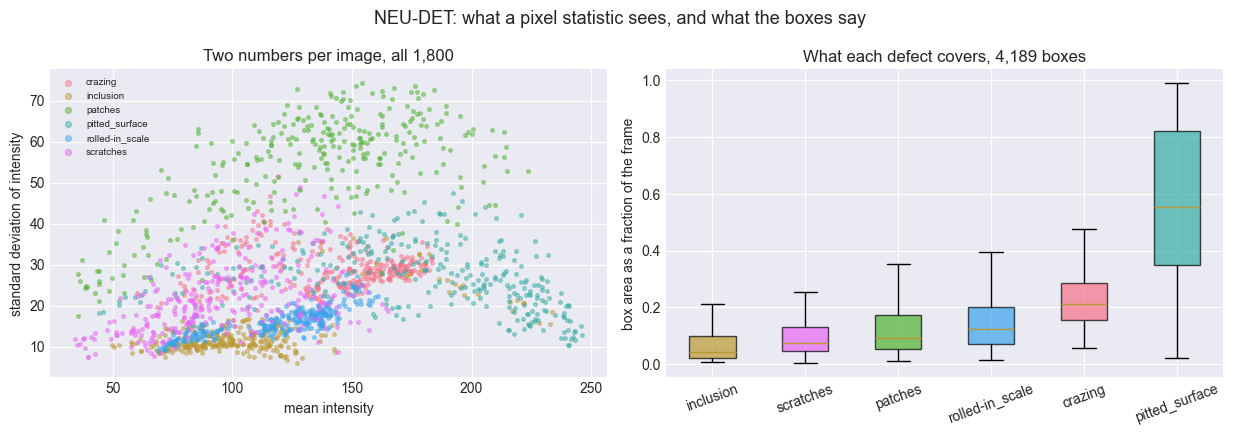

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
palette = dict(zip(CLASSES, sns.color_palette('husl', len(CLASSES))))

for name in CLASSES:
    subset = images[images['folder_class'] == name]
    axes[0].scatter(subset['mean_intensity'], subset['std_intensity'],
                    s=7, alpha=0.45, label=name, color=palette[name])
axes[0].set_xlabel('mean intensity')
axes[0].set_ylabel('standard deviation of intensity')
axes[0].set_title('Two numbers per image, all 1,800')
axes[0].legend(fontsize=7, markerscale=1.6, loc='upper left')

order = list(shape['median_area'].sort_values().index)
data = [boxes.loc[boxes['box_class'] == name, 'area_share'].to_numpy() for name in order]
parts = axes[1].boxplot(data, vert=True, labels=order, showfliers=False, patch_artist=True)
for patch, name in zip(parts['boxes'], order):
    patch.set_facecolor(palette[name])
    patch.set_alpha(0.7)
axes[1].set_ylabel('box area as a fraction of the frame')
axes[1].set_title(f'What each defect covers, {len(boxes):,} boxes')
axes[1].tick_params(axis='x', rotation=20)
fig.suptitle('NEU-DET: what a pixel statistic sees, and what the boxes say', fontsize=13)
fig.tight_layout()
save_figure(fig, 'neu_eda_intensity', subfolder=ASSETS)
plt.show()

## 9. What the images look like

Two rows per class, drawn with the shipped boxes so the label and the evidence for
it sit in the same picture. The top row is a random image of the class. The bottom
row is one of the images section 7 counted, where a second defect class is in the
frame and the folder label does not mention it; where the dataset has no such
image for a class the draw falls back to a random one and the panel says so.

  ✓ Saved → assets\cv\neu_eda_samples.png


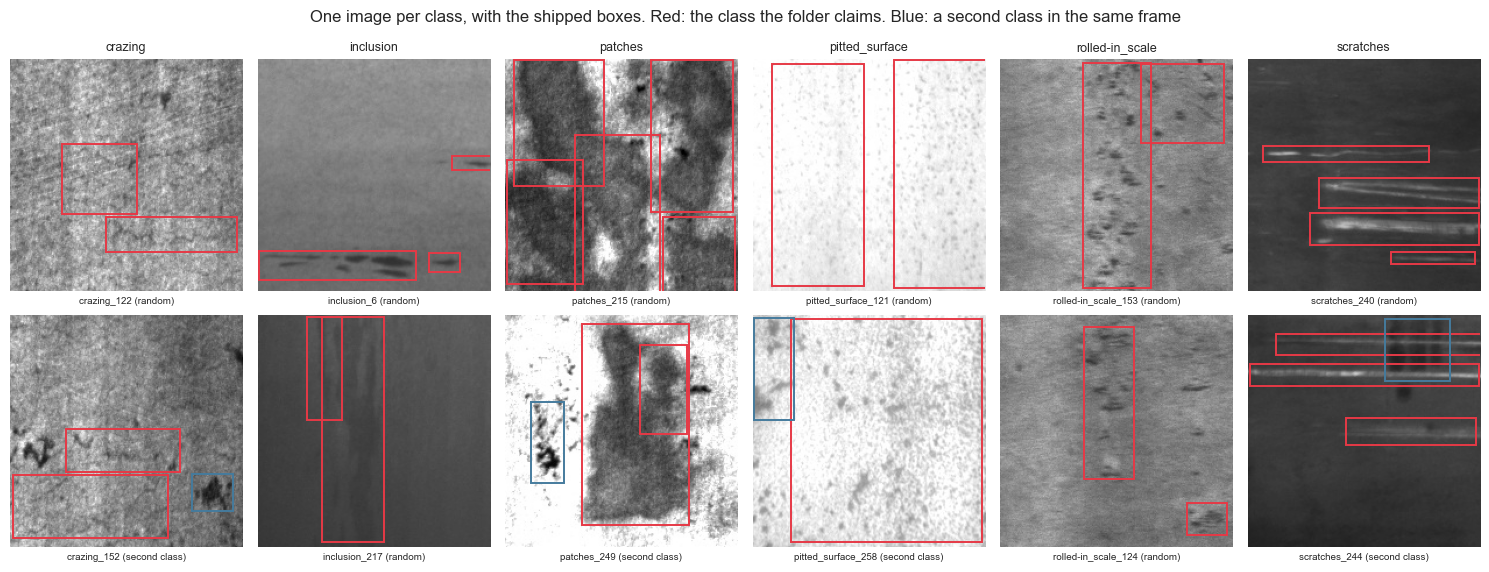

In [13]:
rng = np.random.default_rng(42)
boxes_by_stem = {stem: group for stem, group in boxes.groupby('stem')}
mixed_stems = set(mixed['stem'])

fig, axes = plt.subplots(2, len(CLASSES), figsize=(15, 5.8))
for column, name in enumerate(CLASSES):
    pool = images[images['folder_class'] == name]
    mixed_pool = pool[pool['stem'].isin(mixed_stems)]
    for row in range(2):
        if row == 1 and len(mixed_pool):
            candidates, tag = mixed_pool, 'second class'
        else:
            candidates, tag = pool, 'random'
        pick = candidates.iloc[int(rng.integers(len(candidates)))]
        path = RAW_DIR / pick.split / 'images' / name / f'{pick.stem}.jpg'
        axis = axes[row][column]
        axis.imshow(np.asarray(Image.open(path).convert('L')), cmap='gray', vmin=0, vmax=255)
        drawn = boxes_by_stem.get(pick.stem)
        if drawn is not None:
            for box in drawn.itertuples():
                # Red is the class the folder claims; blue is a second class in the
                # same picture, the 6.8 per cent section 7 counted.
                edge = '#e63946' if box.box_class == name else '#457b9d'
                axis.add_patch(plt.Rectangle(
                    (box.xmin, box.ymin), box.box_width, box.box_height,
                    fill=False, edgecolor=edge, linewidth=1.4))
        axis.set_xticks([]); axis.set_yticks([])
        axis.set_xlabel(f'{pick.stem} ({tag})', fontsize=7)
        if row == 0:
            axis.set_title(name, fontsize=9)
fig.suptitle('One image per class, with the shipped boxes. '
             'Red: the class the folder claims. Blue: a second class in the same frame',
             fontsize=12)
fig.tight_layout()
save_figure(fig, 'neu_eda_samples', subfolder=ASSETS)
plt.show()

## 10. What this notebook found

In [14]:
mixed_share = len(mixed) / len(agreement)
best_baseline = max(baseline.values())
print(f'1. The two folders hold {len(images):,} images, exactly balanced at '
      f'{int(counts.loc["train", CLASSES].max())} train and '
      f'{int(counts.loc["validation", CLASSES].max())} validation per class.')
print(f'2. One stem is filed on both sides of the split: '
      f'{", ".join(s for s, _ in misfiled)} has its image in train and its annotation in validation.')
print(f'3. No image crosses the split. {len(by_pixels)} duplicate group inside one folder, '
      f'{len(across)} across the two.')
print(f'4. {len(mixed):,} images ({mixed_share:.1%}) carry a second defect class that the '
      f'folder label discards. A single-label classifier cannot be right about both.')
print(f'5. Every image is {images["width"].iloc[0]} x {images["height"].iloc[0]} greyscale '
      f'in three identical channels, and the annotations declare depth 1.')
print(f'6. Five of six defect classes occupy under a quarter of the frame; pitted_surface '
      f'covers {shape.loc["pitted_surface", "median_area"]:.2f} of it.')
print(f'7. The strongest pixel-statistic baseline is {best_name}, reaching {best_baseline:.3f} '
      f'accuracy on the validation folder against {1 / len(CLASSES):.3f} chance. That is the floor.')

1. The two folders hold 1,800 images, exactly balanced at 240 train and 60 validation per class.
2. One stem is filed on both sides of the split: crazing_240 has its image in train and its annotation in validation.
3. No image crosses the split. 1 duplicate group inside one folder, 0 across the two.
4. 123 images (6.8%) carry a second defect class that the folder label discards. A single-label classifier cannot be right about both.
5. Every image is 200 x 200 greyscale in three identical channels, and the annotations declare depth 1.
6. Five of six defect classes occupy under a quarter of the frame; pitted_surface covers 0.55 of it.
7. The strongest pixel-statistic baseline is brightness and contrast (2 features), reaching 0.486 accuracy on the validation folder against 0.167 chance. That is the floor.
